<a href="https://colab.research.google.com/github/Dhlih/Submission-Dicoding-Analisis-Sentimen/blob/main/Pelatihan_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [117]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining

import numpy as np  # NumPy untuk komputasi numerik
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca

from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt_tab')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading Dataset

In [118]:
df = pd.read_csv("ulasan_ipusnas.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,82e83362-0763-4eab-9e3d-fc11930634a8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gabisa minjem, kesalahan pengiriman data mulu,...",1,124,2.1.0,2026-02-25 12:21:00,NaN,NaN,2.1.0
1,eb1e116f-41d2-4699-bee6-a86918bbd023,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kadang bisa minjem buku kadang engga, awalnya ...",2,234,2.1.0,2026-02-01 08:49:07,NaN,NaN,2.1.0
2,c28895ee-210a-4be9-81a3-7ad9c1a8b191,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Ini kenapa setelah update data peminjaman, ant...",2,369,2.0.6,2026-01-26 15:43:13,NaN,NaN,2.0.6
3,d6273ac9-49fc-4d54-a80f-d01210795215,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Halo ipusnas! Kenapa dari bulan Januari sampai...,3,31,2.1.0,2026-02-23 06:17:42,NaN,NaN,2.1.0
4,682da2e3-3176-4589-87bb-956495cf64a7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi ini tujuannya memudahkan akses baca s...,1,185,2.1.0,2026-02-22 07:15:35,NaN,NaN,2.1.0


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19959 entries, 0 to 19958
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              19959 non-null  object
 1   userName              19959 non-null  object
 2   userImage             19959 non-null  object
 3   content               19959 non-null  object
 4   score                 19959 non-null  int64 
 5   thumbsUpCount         19959 non-null  int64 
 6   reviewCreatedVersion  14981 non-null  object
 7   at                    19959 non-null  object
 8   replyContent          13130 non-null  object
 9   repliedAt             13130 non-null  object
 10  appVersion            14981 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


In [120]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,4978
at,0
replyContent,6829
repliedAt,6829


In [121]:
clean_df = df.dropna()
clean_df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,0
at,0
replyContent,0
repliedAt,0


In [122]:
clean_df.duplicated().sum()

np.int64(0)

## Preprocess Text

In [123]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [124]:
import json

with open('slang_words.json', 'r') as f:
    slang_words = json.load(f)

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slang_words:
            fixed_words.append(slang_words[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

with open('stop_words.txt', 'r') as f:
    stop_words = set(f.read().splitlines())

def filteringText(text): # Menghapus stopwords dalam teks
    filtered = []
    for txt in text:
        if txt not in stop_words:
            filtered.append(txt)
    text = filtered
    return text

In [125]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [126]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
23,d5f0a704-9260-47f4-960d-153ab64d6cf4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Setelah diupdate krn keperluan tugas, rupanya ...",1,46,2.0.6,2026-01-29 01:38:27,Hallo Liliy! Terima kasih sudah memberikan ula...,2022-03-27 08:52:58,2.0.6,Setelah diupdate krn keperluan tugas rupanya g...,setelah diupdate krn keperluan tugas rupanya g...,setelah diupdate karena keperluan tugas rupany...,"[setelah, diupdate, karena, keperluan, tugas, ...","[diupdate, keperluan, tugas, rupanya, gak, bis...",diupdate keperluan tugas rupanya gak bisa logi...
28,27609d0c-739b-4a34-847b-ff4a6a8c3fdc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya Download Aplikasi Ipusnas Langsung di Pla...,1,12,2.0.6,2026-01-25 02:42:18,Hallo Usman! Kami mohon maaf atas kendala dan ...,2023-04-01 11:01:42,2.0.6,Saya Download Aplikasi Ipusnas Langsung di Pla...,saya download aplikasi ipusnas langsung di pla...,saya download aplikasi ipusnas langsung di pla...,"[saya, download, aplikasi, ipusnas, langsung, ...","[download, aplikasi, ipusnas, langsung, playst...",download aplikasi ipusnas langsung playstorre ...
33,96709d16-28e3-4dc9-aef2-7562a85b129e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Terima kasih sudah memberi kesempatan untuk ya...,2,3,2.0.6,2026-01-24 23:28:33,Hallo Puristi! Kami mohon maaf atas ketidaknya...,2024-09-09 01:34:17,2.0.6,Terima kasih sudah memberi kesempatan untuk ya...,terima kasih sudah memberi kesempatan untuk ya...,terima kasih sudah memberi kesempatan untuk ya...,"[terima, kasih, sudah, memberi, kesempatan, un...","[terima, kasih, sudah, kesempatan, ingin, memb...",terima kasih sudah kesempatan ingin membaca be...
41,03dc5e28-0e6f-403a-87f1-694e00c29b5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,astaga ipusnas... kenapa makin jelek aja sih.....,1,15,2.0.6,2026-01-29 23:28:07,Hallo Pujiana! Kami mohon maaf atas ketidaknya...,2023-10-01 07:16:16,2.0.6,astaga ipusnas kenapa makin jelek aja sih sebe...,astaga ipusnas kenapa makin jelek aja sih sebe...,astaga ipusnas kenapa makin jelek saja sih seb...,"[astaga, ipusnas, kenapa, makin, jelek, saja, ...","[astaga, ipusnas, makin, jelek, sih, update, t...",astaga ipusnas makin jelek sih update tidak bi...
54,b74d631a-0828-44db-bea5-8d459c8ca039,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Koleksi bukunya banyak banget! Meski harus nga...,5,2,2.1.0,2026-02-13 03:10:28,Hallo Pine! Kami mohon maaf atas kendala dan k...,2024-05-20 22:44:26,2.1.0,Koleksi bukunya banyak banget Meski harus ngan...,koleksi bukunya banyak banget meski harus ngan...,koleksi bukunya banyak banget meski harus meng...,"[koleksi, bukunya, banyak, banget, meski, haru...","[koleksi, bukunya, banyak, banget, meski, haru...",koleksi bukunya banyak banget meski harus meng...


## Pelabelan

In [127]:
def label_sentiment(score):
  if score < 3:
    return "negative"
  elif score == 3:
    return "neutral"
  else:
    return "positive"

clean_df["polarity"] = clean_df["score"].apply(label_sentiment)

In [129]:
mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

clean_df['polarity_encoded'] = clean_df['polarity'].map(mapping)
print(clean_df[['polarity', 'polarity_encoded']].head())

    polarity  polarity_encoded
23  negative                 0
28  negative                 0
33  negative                 0
41  negative                 0
54  positive                 2


([<matplotlib.patches.Wedge at 0x7bcee39e0a40>,
 [Text(-0.05851248929873245, 1.0984426651382702, '2'),
  Text(-0.4934916507475178, -0.9830900216371287, '0'),
  Text(0.9554478644753052, -0.5450865786914763, '1')],
 [Text(-0.03191590325385406, 0.5991505446208746, '51.7%'),
  Text(-0.2691772640441006, -0.5362309208929792, '31.8%'),
  Text(0.5211533806228937, -0.2973199520135325, '16.5%')])

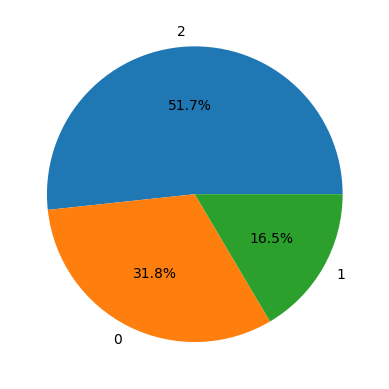

In [133]:
plt.pie(clean_df["polarity_encoded"].value_counts(), labels=clean_df["polarity"].value_counts().index, autopct='%1.1f%%')

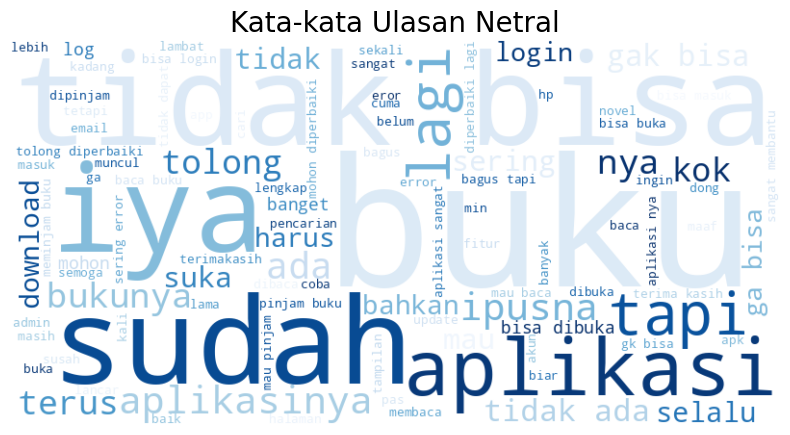

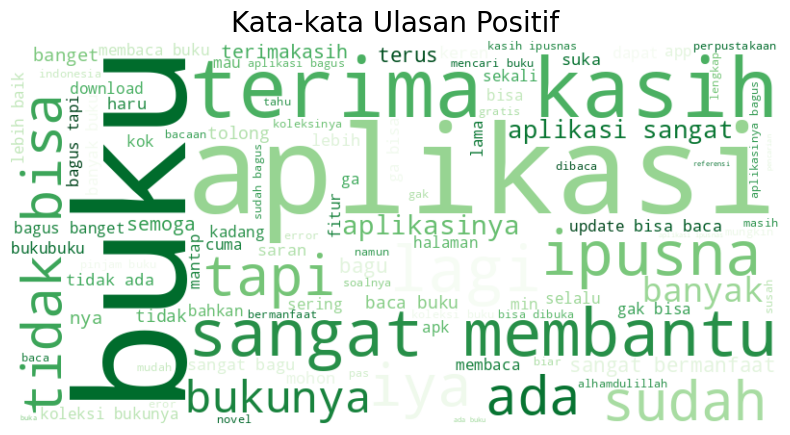

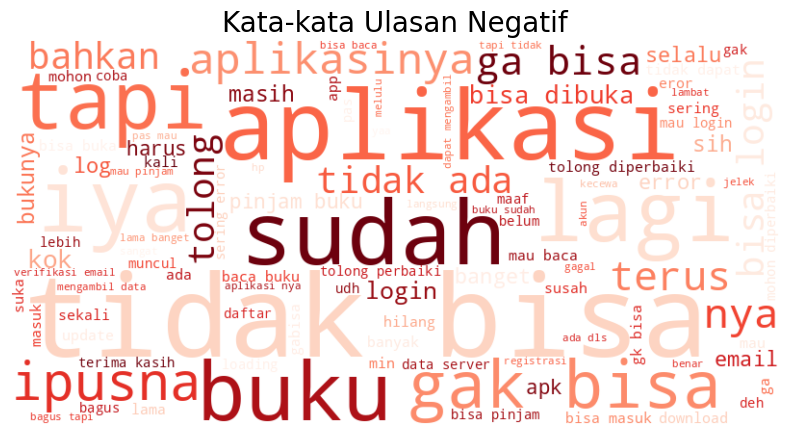

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Pisahkan data berdasarkan polaritas
data_negatif = clean_df[clean_df['polarity_encoded'] == 0]['text_akhir']
data_netral = clean_df[clean_df['polarity_encoded'] == 1]['text_akhir']
data_positif = clean_df[clean_df['polarity_encoded'] == 2]['text_akhir']

# 2. Gabungkan semua baris teks menjadi satu string panjang
teks_negatif = " ".join(review for review in data_negatif)
teks_netral = " ".join(review for review in data_netral)
teks_positif = " ".join(review for review in data_positif)

# 3. Fungsi untuk membuat Word Cloud
def buat_wordcloud(teks, judul, warna_peta):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=warna_peta, # 'Greens' untuk positif, 'Reds' untuk negatif
        max_words=100
    ).generate(teks)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(judul, fontsize=20)
    plt.axis('off')

    plt.show()

buat_wordcloud(teks_netral, "Kata-kata Ulasan Netral", "Blues")

# 4. Tampilkan Word Cloud Positif
buat_wordcloud(teks_positif, "Kata-kata Ulasan Positif", "Greens")

# 5. Tampilkan Word Cloud Negatif
buat_wordcloud(teks_negatif, "Kata-kata Ulasan Negatif", "Reds")

## Data Splitting dan Ekstraksi Fitur

In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [169]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity_encoded']

# Ekstraksi fitur dengan TF-IDF
# max_df = abaikan kata yang muncul lebih dari 80% total ulasan, min_df =  abaikan kata yang muncul kurang dari 17x
tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Menampilkan hasil ekstraksi fitur
print("Shape dataframe : ", features_df.shape)
features_df

Shape dataframe :  (10065, 4863)


,aamiin,ada,ada ada,ada antrian,ada apk,ada aplikasi,ada app,ada bahkan,ada banyak,ada batas,...,yaaa,yah,yah sudah,yahh,yak,yakin,you,youtube,zaman,zoom
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.120744,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.121196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.219682,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10060,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10061,0.0,0.229060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10062,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10063,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [170]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression(class_weight="balanced")

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_lr)
print('Random Forest - accuracy_test:', accuracy_test_lr)

Random Forest - accuracy_train: 0.813089915548932
Random Forest - accuracy_test: 0.6696472925981123


In [166]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Classification Report:")
print(classification_report(y_test, y_pred_test_lr, target_names=['negatif', 'netral', 'positif']))

Classification Report:
              precision    recall  f1-score   support

     negatif       0.62      0.64      0.63       640
      netral       0.29      0.39      0.33       332
     positif       0.86      0.75      0.80      1041

    accuracy                           0.65      2013
   macro avg       0.59      0.59      0.59      2013
weighted avg       0.69      0.65      0.67      2013



In [172]:
from sklearn.svm import LinearSVC

# LinearSVC cenderung lebih kuat untuk fitur TF-IDF yang banyak
model_svc = LinearSVC(class_weight='balanced', random_state=42)
model_svc.fit(X_train, y_train) # Tidak perlu .toarray(), SVC mendukung sparse matrix

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svc = model_svc.predict(X_train.toarray())
y_pred_test_svc = model_svc.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_svc = accuracy_score(y_pred_train_svc, y_train)
accuracy_test_svc = accuracy_score(y_pred_test_svc, y_test)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_svc)
print('Random Forest - accuracy_test:', accuracy_test_svc)

Random Forest - accuracy_train: 0.9080973671137605
Random Forest - accuracy_test: 0.6602086438152012


In [174]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Classification Report:")
print(classification_report(y_test, y_pred_test_svc, target_names=['negatif', 'netral', 'positif']))

Classification Report:
              precision    recall  f1-score   support

     negatif       0.61      0.65      0.63       640
      netral       0.31      0.31      0.31       332
     positif       0.81      0.78      0.80      1041

    accuracy                           0.66      2013
   macro avg       0.58      0.58      0.58      2013
weighted avg       0.67      0.66      0.66      2013



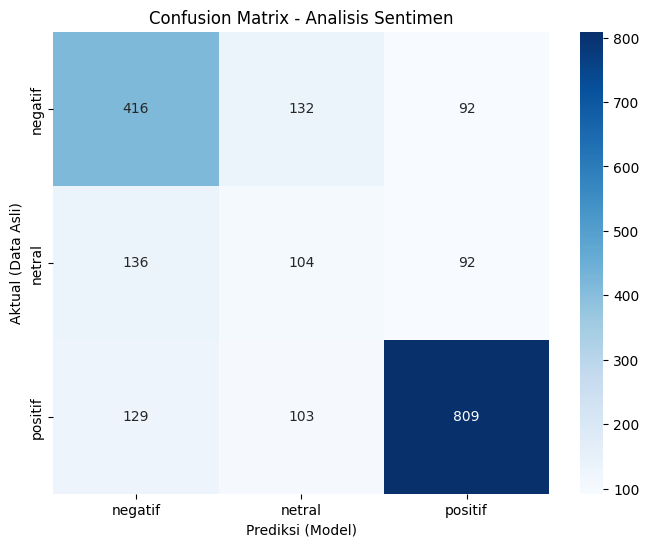

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Hitung Confusion Matrix
# Pastikan y_test (data asli) dan y_pred_test_lr (hasil prediksi) sudah tersedia
cm = confusion_matrix(y_test, y_pred_test_svc)

# 2. Definisikan label sesuai urutan encoding (0: negatif, 1: netral, 2: positif)
labels = ['negatif', 'netral', 'positif']

# 3. Visualisasi menggunakan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - Analisis Sentimen')
plt.xlabel('Prediksi (Model)')
plt.ylabel('Aktual (Data Asli)')
plt.show()